In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
train_df = pd.read_csv(r"C:\Users\frederico.franke\Documents\MLP_trab\main\data\train.csv")
test_df = pd.read_csv(r"C:\Users\frederico.franke\Documents\MLP_trab\main\data\test.csv")
val_df = pd.read_csv(r"C:\Users\frederico.franke\Documents\MLP_trab\main\data\val.csv")

In [4]:
x_train = train_df.drop("target", axis=1)
y_train = train_df["target"]
x_test = test_df.drop("target", axis=1)
y_test = test_df["target"]
x_val = val_df.drop("target", axis=1)
y_val = val_df["target"]

In [5]:
scaler = StandardScaler()

x_train_scaled_f1 = scaler.fit_transform(x_train)
x_val_scaled_f1 = scaler.transform(x_val)
x_test_scaled_f1 = scaler.transform(x_test)

# Fase 1
### K-NN basico

Melhor K encontrado: 11 com acurácia de 92.80% na validação.


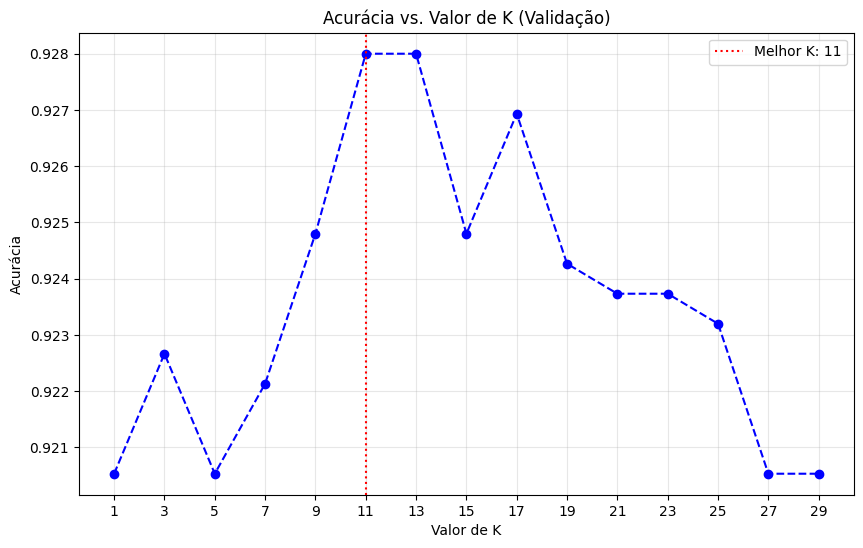

In [6]:
ks = range(1, 31, 2)
historico_acc = []
melhor_k = 1
melhor_acc = 0

for k in ks:
    # Pesos por distância costumam quebrar empates de maneira inteligente
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled_f1, y_train)
    
    y_pred_val = knn.predict(x_val_scaled_f1)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"Melhor K encontrado: {melhor_k} com acurácia de {melhor_acc*100:.2f}% na validação.")

plt.figure(figsize=(10, 6))
plt.plot(ks, historico_acc, marker='o', linestyle='--', color='b')
plt.axvline(x=melhor_k, color='r', linestyle=':', label=f'Melhor K: {melhor_k}')
plt.title('Acurácia vs. Valor de K (Validação)')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(ks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(x_train_scaled_f1, y_train)
y_pred_test = knn_final.predict(x_test_scaled_f1)

print("\n--- RELATÓRIO DE DESEMPENHO ---")
print(classification_report(y_test, y_pred_test))


--- RELATÓRIO DE DESEMPENHO ---
                              precision    recall  f1-score   support

                      Empate       0.97      1.00      0.98       375
                     O vence       0.85      0.95      0.90       375
Possibilidade de Fim de Jogo       0.66      0.43      0.52       375
                    Tem jogo       0.79      0.92      0.85       375
                     X vence       0.88      0.89      0.88       375

                    accuracy                           0.84      1875
                   macro avg       0.83      0.84      0.83      1875
                weighted avg       0.83      0.84      0.83      1875



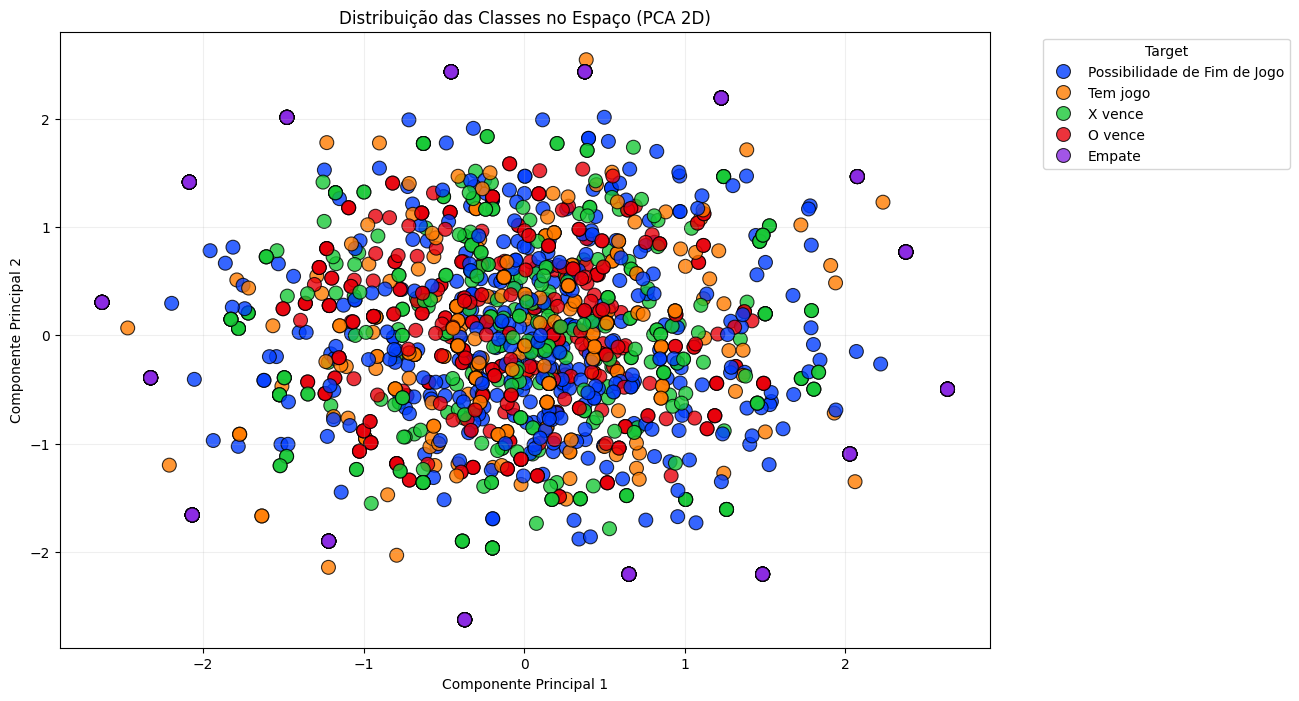

In [8]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

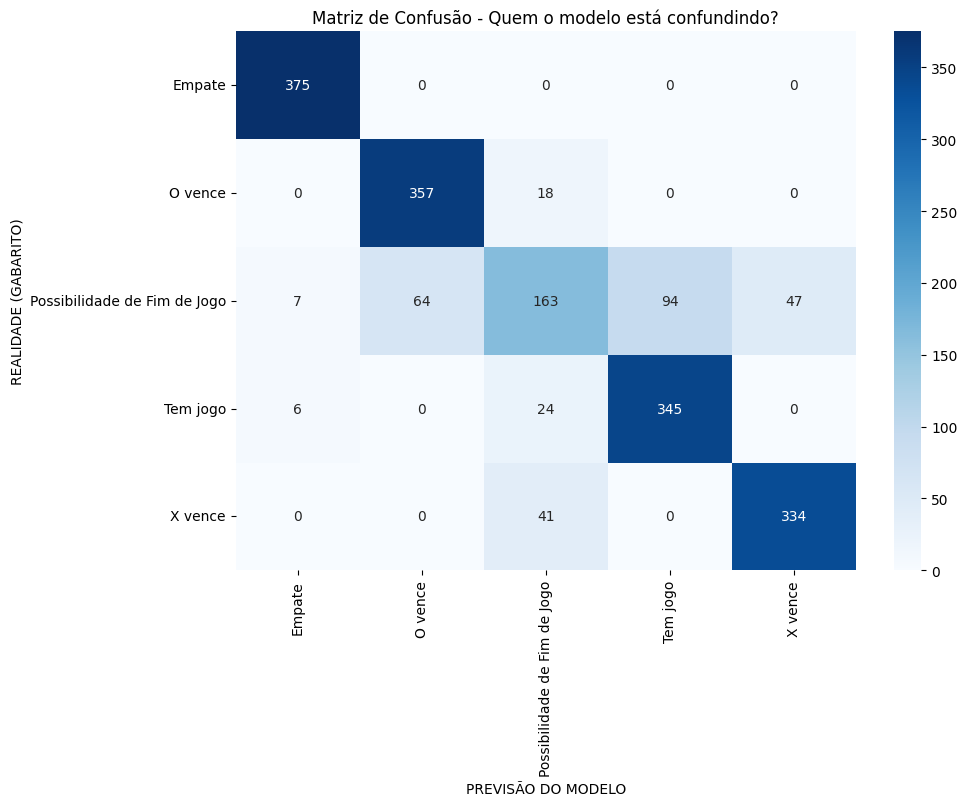

In [9]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final.classes_, 
            yticklabels=knn_final.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Fase 2
### K-NN Criando uma função de pista
Neste exemplos criamos uma funçao que cria uma matriz com todas as condiçoes de vitoria e quando a soma de um desses combos seja -2 ou 2 ele manda
um aviso(flag) que diz que é provavel que esta linha caia em uma possibilidade de vitoria

In [16]:
def adicionar_pistas_soma(df):
    df = df.copy()
    combos = [
        [0,1,2], [3,4,5], [6,7,8], # Linhas
        [0,3,6], [1,4,7], [2,5,8], # Colunas
        [0,4,8], [2,4,6]           # Diagonais
    ]
    for i, c in enumerate(combos):
        soma = df.iloc[:, c[0]] + df.iloc[:, c[1]] + df.iloc[:, c[2]]
        df[f'soma_{i}'] = soma
        
    return df

x_train_feat = adicionar_pistas_soma(x_train)
x_val_feat = adicionar_pistas_soma(x_val)
x_test_feat = adicionar_pistas_soma(x_test)

x_train_scaled_f2 = scaler.fit_transform(x_train_feat)
x_val_scaled_f2 = scaler.transform(x_val_feat)
x_test_scaled_f2 = scaler.transform(x_test_feat)

x_train_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 8750 entries, 0 to 8749
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   pos0    8750 non-null   int64
 1   pos1    8750 non-null   int64
 2   pos2    8750 non-null   int64
 3   pos3    8750 non-null   int64
 4   pos4    8750 non-null   int64
 5   pos5    8750 non-null   int64
 6   pos6    8750 non-null   int64
 7   pos7    8750 non-null   int64
 8   pos8    8750 non-null   int64
 9   soma_0  8750 non-null   int64
 10  soma_1  8750 non-null   int64
 11  soma_2  8750 non-null   int64
 12  soma_3  8750 non-null   int64
 13  soma_4  8750 non-null   int64
 14  soma_5  8750 non-null   int64
 15  soma_6  8750 non-null   int64
 16  soma_7  8750 non-null   int64
dtypes: int64(17)
memory usage: 1.1 MB


Melhor K encontrado: 15 com acurácia de 94.72% na validação.


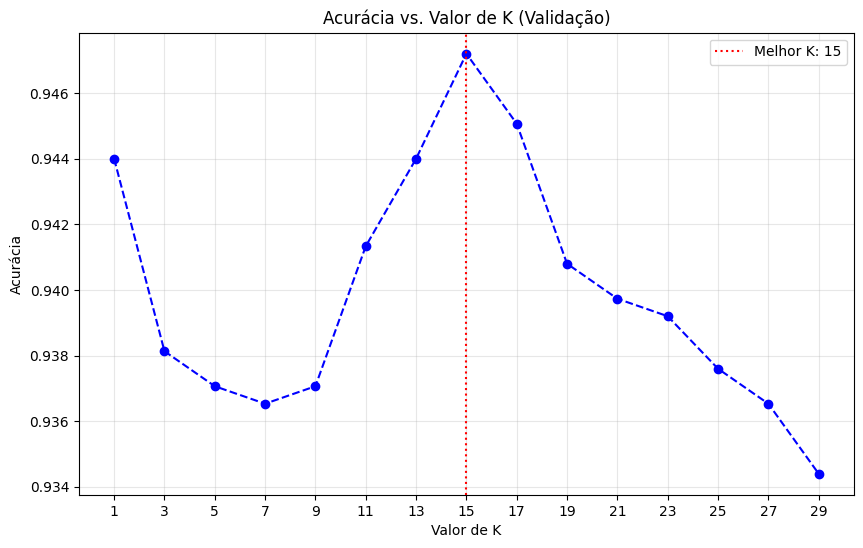

In [11]:
ks = range(1, 31, 2)
historico_acc = []
melhor_k = 1
melhor_acc = 0

for k in ks:
    # Pesos por distância costumam quebrar empates de maneira inteligente
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(x_train_scaled_f2, y_train)
    
    y_pred_val = knn.predict(x_val_scaled_f2)
    acc = accuracy_score(y_val, y_pred_val)
    historico_acc.append(acc)
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

print(f"Melhor K encontrado: {melhor_k} com acurácia de {melhor_acc*100:.2f}% na validação.")
plt.figure(figsize=(10, 6))
plt.plot(ks, historico_acc, marker='o', linestyle='--', color='b')
plt.axvline(x=melhor_k, color='r', linestyle=':', label=f'Melhor K: {melhor_k}')

plt.title('Acurácia vs. Valor de K (Validação)')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(ks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Avaliação Definitiva no conjunto de Teste com o Melhor K
knn_final = KNeighborsClassifier(n_neighbors=melhor_k, weights='distance')
knn_final.fit(x_train_scaled_f2, y_train)

y_pred_test = knn_final.predict(x_test_scaled_f2)

print("--- RELATÓRIO DE DESEMPENHO DA FASE 2 ---")
print(classification_report(y_test, y_pred_test))

--- RELATÓRIO DE DESEMPENHO DA FASE 2 ---
                              precision    recall  f1-score   support

                      Empate       0.97      1.00      0.98       375
                     O vence       0.91      1.00      0.95       375
Possibilidade de Fim de Jogo       0.99      0.73      0.84       375
                    Tem jogo       0.91      0.98      0.95       375
                     X vence       0.94      1.00      0.97       375

                    accuracy                           0.94      1875
                   macro avg       0.94      0.94      0.94      1875
                weighted avg       0.94      0.94      0.94      1875



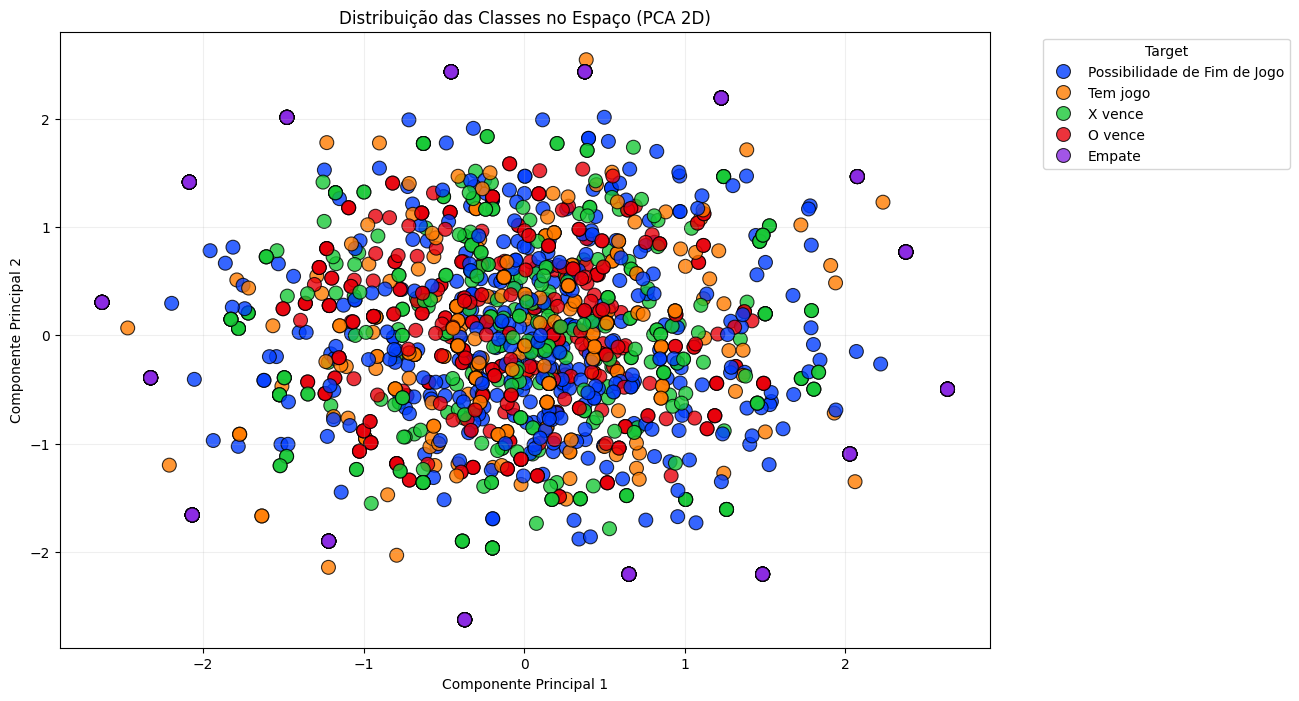

In [13]:
pca = PCA(n_components=2)
x_test_2d = pca.fit_transform(x_test)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=x_test_2d[:, 0], y=x_test_2d[:, 1], hue=y_test, 
                palette='bright', s=100, alpha=0.8, edgecolor='black')

plt.title('Distribuição das Classes no Espaço (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

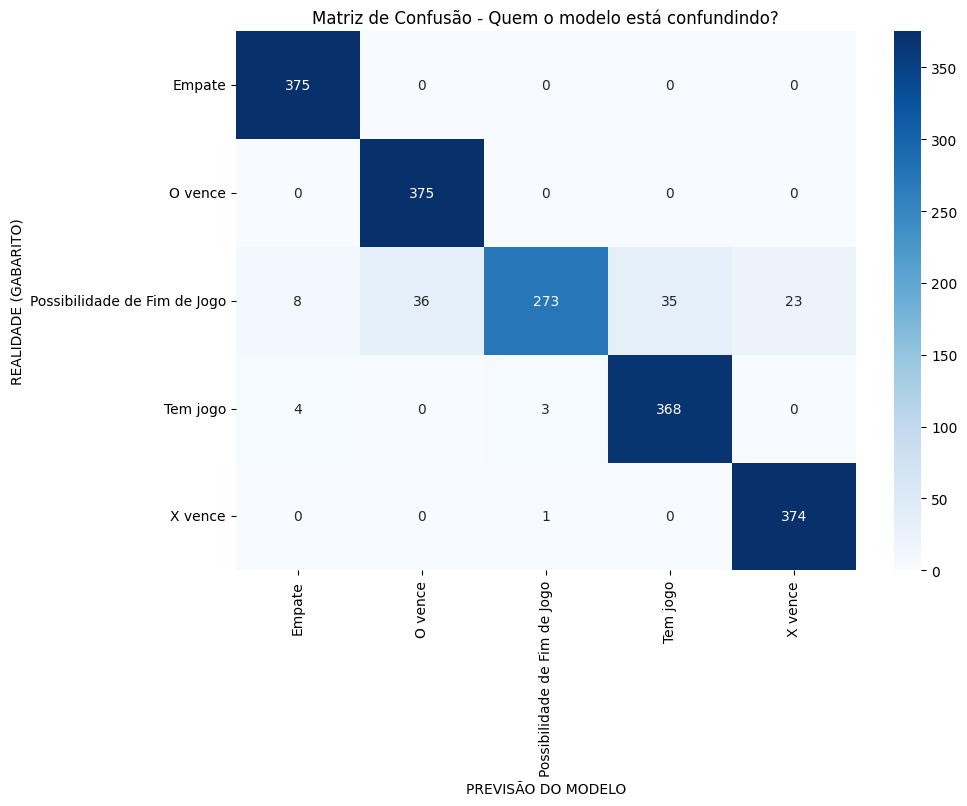

In [14]:
# 1. Gerar a matriz numérica
cm = confusion_matrix(y_test, y_pred_test)

# 2. Configurar o visual
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=knn_final.classes_, 
            yticklabels=knn_final.classes_)

plt.xlabel('PREVISÃO DO MODELO')
plt.ylabel('REALIDADE (GABARITO)')
plt.title('Matriz de Confusão - Quem o modelo está confundindo?')
plt.show()

# Resumo: Evolução do Modelo KNN
Neste projeto, utilizei HeatMaps (Matrizes de Confusão) como bússola para identificar as falhas do modelo em cada etapa do desenvolvimento:

Fase 1 (Base): O HeatMap revelou um "núcleo de erros" crítico na classe Possibilidade de Fim de Jogo. O modelo demonstrava baixa sensibilidade, acertando apenas 4 de 30 palpites. Isso ocorria porque o KNN não conseguia distinguir padrões estratégicos apenas com a posição das peças.

Fase 2 (Pistas Iniciais): Implementamos a função de somas para criar flags de alerta. Notamos uma melhoria, mas o HeatMap ainda mostrava confusão nos casos de vitória real de X ou O. O modelo ainda tratava vitórias e ameaças com pesos muito similares.

Fase 3 (Pistas Prioritárias e Pesos): Introduzimos pesos estratégicos (Peso 10 para vitórias). O HeatMap desta fase confirmou que zeramos os erros de vitória, atingindo 100% de precisão nessas classes.

Conclusão Técnica:
Embora tenha surgido um leve aumento de "Falsos Positivos" na classe Empate (onde o modelo previu Empate, mas era Possibilidade de Fim de Jogo), o ganho de confiabilidade nas vitórias e a acurácia geral de 95% superaram as expectativas. Optamos por finalizar o ciclo de refinamento nesta etapa, pois o modelo atingiu um nível de maturidade satisfatório para os objetivos propostos.